In [1]:
import numpy as np
import pandas as pd
import math
import os, sys
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer

from utils.utilities import *

In [2]:
class Dataset:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, i):
        if isinstance(i, (pd.Series, np.ndarray)) and i.dtype == bool:
            return Dataset(self.x[i], self.y[i])
        return self.x[i], self.y[i]
    
    def copy(self, deep=True):
        if deep:
            return Dataset(self.x.copy(), self.y.copy())
        else:
            return Dataset(self.x, self.y)
    
def to_dataset(df, target):
    mask = ~df.columns.isin([target])
    x = df.loc[:, mask]
    y = df[target]

    return Dataset(x, y)

# Load Data


In [3]:
df_dt = pd.read_csv('../data/flight_data_2024_data_dictionary.csv')
df1 = pd.read_csv('../data/archive/flight_24.csv', low_memory=False)
df2 = pd.read_csv('../data/archive/flight_25.csv', low_memory=False)

# Convert DType


In [4]:
dtypes = dict(zip(df_dt['column'], df_dt['dtype']))
df1 = df1.drop(columns=['fl_date'])
df2 = df2.drop(columns=['fl_date'])

In [5]:
def dtype_converter(df: pd.DataFrame, dtype_dict: dict):
    for col in df.columns:
        if col == 'fl_date':
            continue
        if df[col].isna().sum() != 0 and (dtype_dict[col] == 'int64' or dtype_dict[col] == 'int32'):
            df[col] = df[col].astype('Int64')
        else:
            df[col] = df[col].astype(dtype_dict[col])

    return df

In [6]:
df1 = dtype_converter(df1, dtypes)
df2 = dtype_converter(df2, dtypes)
df = pd.concat([df1, df2], axis=0)

# Data Engineering


# Data Preprocessing


## Filter


In [7]:
thres = 0.2
n = len(df)
na_cols = []
for idx, val in df.isna().sum().items():
    if val > (thres * n):
        na_cols.append(idx)

df_filtered = df.drop(columns=na_cols, errors='ignore')

In [8]:
df_filtered = df_filtered.dropna(subset=['arr_delay'])

In [9]:
leakage_cols = [
    'dep_time', 'dep_delay', 'dep_delay_new',
    'arr_time',
    'actual_elapsed_time', 'air_time',
    'taxi_in', 'taxi_out',
    'wheels_on', 'wheels_off',
    'carrier_delay', 'weather_delay', 'nas_delay',
    'security_delay', 'late_aircraft_delay'
]

redundant_cols = [
    'origin_state_nm',
    'origin_city_name',
    'dest_state_nm',
    'dest_city_name',
    'op_carrier_fl_num',
    'cancellation_code',
    'cancelled',
    'diverted',
    'fl_date',
    'year',
    'crs_dep_time',
    'dep_datetime',
    'weather_hour',
    'datetime'
]

df_filtered = df_filtered.drop(columns=leakage_cols, errors='ignore')
df_filtered = df_filtered.drop(columns=redundant_cols, errors='ignore')

In [10]:
low = df_filtered['arr_delay'].quantile(0.001)
high = df_filtered['arr_delay'].quantile(0.999)
mask = (df_filtered['arr_delay'].between(low, high) | df_filtered['arr_delay'].isna())
df_filtered = df_filtered[mask]

df_filtered = df_filtered[df_filtered['distance'] >= 15]
df_filtered = df_filtered[~((df_filtered['distance'] / df_filtered['crs_elapsed_time'] * 60 > 400) & (df_filtered['crs_elapsed_time'] < 30))]

ds = to_dataset(df_filtered, 'arr_delay')

ds = encode_weather(ds, 'weather_code')

for col in ds.x.select_dtypes(include=['object', 'str']).columns:
    ds.x[col] = ds.x[col].astype('category')

## Fill Missing


In [11]:
def fill_missing(ds, group: list):
    X, y = ds[:]
    
    for col in tqdm(X.columns):
        if X[col].isna().sum() == 0:
            continue
        
        if isinstance(X[col].dtype, pd.CategoricalDtype):
            X[col] = X[col].cat.add_categories(['Unknown'])
            X[col] = X[col].fillna('Unknown')
        else:
            global_median = X[col].median()
            group_median = X.groupby(group, observed=True)[col]\
                            .transform('median')
            
            X[col] = X[col].fillna(group_median)
            X[col] = X[col].fillna(global_median)
        
    return Dataset(X, y)

In [12]:
group = ['month', 'op_unique_carrier', 'origin_state_nm', 'dest_state_nm']
ds_filled = fill_missing(ds, group)

100%|██████████| 19/19 [00:00<00:00, 58.12it/s]


## Balancing Features


In [13]:
class GroupCat:
    def __init__(self):
        self.cat_dict = dict()
        self.thresh_dict = dict()

    def fit(
            self,
            ds,
            cols: np.ndarray = None,
            min_freq: np.ndarray = None,
            min_pct: np.ndarray = None
    ):
        if cols is None:
            raise ValueError
        self.cols = cols

        if min_pct is not None:
            if len(min_pct) != len(cols):
                raise ValueError(f'Expecting min_pct of len {len(cols)} (got {len(min_pct)})')
            
            threshold = min_pct * len(ds)

        elif min_freq is not None:
            if len(min_freq) != len(cols):
                raise ValueError(f'Expecting min_freq of len {len(cols)} (got {len(min_freq)})')
            
            threshold = min_freq
            
        else:
            raise ValueError('Arguments min_freq or min_pct cannot be empty.')
        
        X, y = ds[:]

        self.thresh_dict = dict(zip(cols, threshold))
        for col in cols:
            counts = X[col].value_counts()
            keep_cat = counts[counts >= self.thresh_dict[col]].index
            self.cat_dict[col] = keep_cat

        return self
    
    def transform(self, ds):        
        X, y = ds[:]
        
        for col in self.cols:
            if X[col].dtype != 'category':
                X[col] = X[col].astype('category')

            keep_cat = self.cat_dict[col]

            X[col] = X[col].cat.add_categories(['Other'])
            X.loc[~X[col].isin(keep_cat), col] = 'Other'
            X[col] = X[col].cat.remove_unused_categories()

        return Dataset(X, y)

In [25]:
cat_cols = np.array(['op_unique_carrier', 'origin', 'dest'])
min_pct = np.array([0.02, 0.002, 0.002])

gr = GroupCat()
gr.fit(ds_filled, cat_cols, min_pct=min_pct)
ds_grouped = gr.transform(ds_filled)

## One-hot Encoding


In [15]:
def analyze_cardinality(
        df: pd.DataFrame | None = None,
):
    if not isinstance(df, pd.DataFrame):
        raise TypeError('Input should be a DataFrame.')
    
    cat_cols = df.select_dtypes(include=['category', 'object', 'string']).columns
    low_card = []
    high_card = []

    n_unique = df.loc[:, cat_cols].nunique()
    mask = n_unique <= 20
    low_card.extend(mask[mask].index.tolist())
    high_card.extend(mask[~mask].index.tolist())

    return low_card, high_card

def OHE(ds, columns=None, drop_first=False):
    if columns is None: raise ValueError

    X, y = ds[:]
    X = pd.get_dummies(X, columns=columns, drop_first=drop_first)

    return Dataset(X, y)

In [16]:
low_card, high_card = analyze_cardinality(ds_grouped.x)

ds_encoded = OHE(ds_grouped, columns=low_card, drop_first=False)

## Split Data


In [17]:
def train_val_test_split(ds, val_size=0.1, test_size=0.15, **kwargs):
    train_size = 1. - val_size - test_size
    assert abs(val_size + test_size) < 1. + 1e-6, "Sum of validation size and test size is greater than 1"

    X, y = ds[:]

    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y,
        test_size=(1 - train_size),
        **kwargs
    )

    val_ratio = val_size / (val_size + test_size)

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=(1 - val_ratio),
        **kwargs
    )

    return Dataset(X_train, y_train), Dataset(X_val, y_val), Dataset(X_test, y_test)

In [18]:
train_ds, val_ds, test_ds = train_val_test_split(ds_encoded, random_state=21)

## Target Encoding


In [19]:
class TargetEncoder:
    def __init__(self):
        self.mappings = {}

    def fit(
            self,
            ds: Dataset,
            cols: list | np.ndarray | None = None,
            smoothing: float | None = 0.0
    ):
        if cols is None or not cols:
            cols = ds.x.select_dtypes(include='category').columns.tolist()
        
        X = ds.x.copy()
        X['__target__'] = ds.y
        self.cols = cols

        for col in cols:
            mean = X['__target__'].mean()
            stats = X.groupby(col, observed=True)['__target__'].agg(['mean', 'count'])
            smooth = (stats['count'] * stats['mean'] + smoothing * mean) / (stats['count'] + smoothing)

            self.mappings[col] = (smooth, mean)

        return self
    
    def transform(
            self,
            ds: Dataset,
    ):
        ds_enc = Dataset(ds.x.copy(), ds.y.copy())

        for col in self.cols:
            smooth, mean = self.mappings[col]
            ds_enc = Dataset(ds_enc.x.copy(), ds_enc.y.copy())
            ds_enc.x[col] = ds_enc.x[col].astype('object').map(smooth).fillna(mean)

        return ds_enc

In [20]:
Encoder = TargetEncoder()
Encoder.fit(train_ds, high_card, smoothing=10.)

train_encoded = Encoder.transform(train_ds)
val_encoded = Encoder.transform(val_ds)
test_encoded = Encoder.transform(test_ds)

## Feature Selection


### Information Gain


In [23]:
class InformationGain():
    def __init__(self):
        self.score_dict = dict()

    def score(self, ds: Dataset, bins: int = 10) -> dict:
        X, y = ds[:]
        y = np.array(y)

        for col in tqdm(X.columns, desc='Column'):
            x_col = np.array(X[col])

            if X[col].dtype.kind in 'bifc' and len(np.unique(x_col)) > bins:
                x_col = pd.qcut(X[col], bins, duplicates='drop').cat.codes.to_numpy()

            self.score_dict[col] = self._ig(x_col, y)

        return dict(sorted(self.score_dict.items(), key=lambda item: item[1], reverse=True))

    def _ig(self, x: np.ndarray, y: np.ndarray) -> float:
        ent_Y = entropy(y)
        ent_YX = 0.

        values, counts = np.unique(x, return_counts=True)
        for val, count in zip(values, counts):
            group_y = y[x == val]
            ent_YX += (count / len(y)) * entropy(group_y)

        return ent_Y - ent_YX

### Correlation Filtering


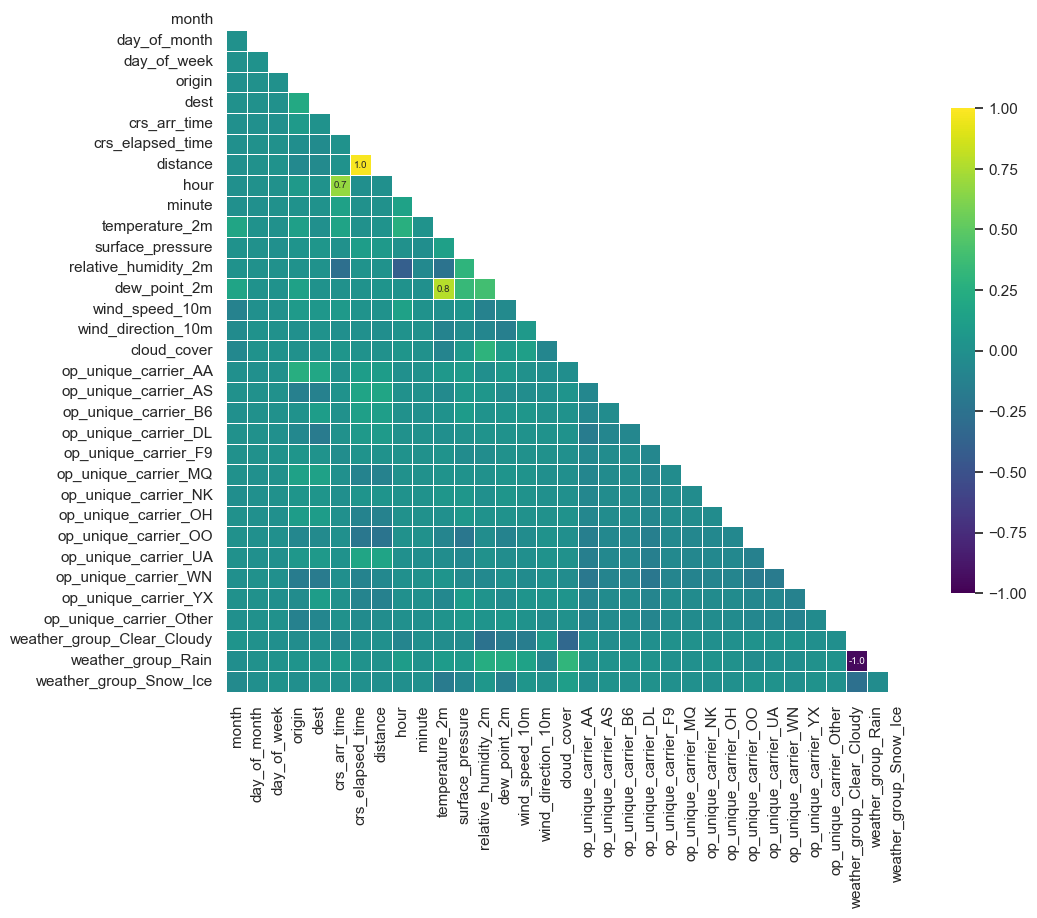

In [26]:
sns.set_theme(style='white')

Xs = train_encoded.x.astype('float64')
cols = Xs.columns
X_corr = np.corrcoef(Xs.to_numpy().T)# Xs.corr()
mask = np.triu(np.ones_like(X_corr, dtype=bool))
annot_matrix = np.where(np.abs(X_corr) >= 0.6, 
                        np.round(X_corr, 1).astype(str), 
                        "")

f, ax = plt.subplots(figsize=(11,9))
cmap = sns.color_palette('viridis', as_cmap=True)
sns.heatmap(X_corr,
            mask=mask,
            cmap=cmap,
            annot=annot_matrix,
            annot_kws={'fontsize':7},
            fmt="",
            xticklabels=cols,
            yticklabels=cols,
            vmax=1, vmin=-1,
            center=0,
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": .7},
            
    );

### Filtering


In [57]:
# Refactor
class Filter:
    def __init__(self):
        self.IG = None
        self.keep_feat = None

    def fit(self, ds, ig_thresh=1e-3):
        X, y = ds[:]

        IG_dict = {}
        for col in X.columns:
            ig = IG(ds, col)
            IG_dict[col] = ig
        IG_dict = {key: value for key,
                   value in sorted(IG_dict.items(), reverse=True,
                                   key=lambda item: item[1])}
        
        IG_filtered = {k: v for k, v in IG_dict.items() if v > ig_thresh}
        self.keep_feat = list(IG_filtered.keys())

    def transform(self, ds):
        if self.keep_feat is None:
            raise ValueError
        
        X, y = ds[:]
        X = X.loc[:, self.keep_feat]

        return Dataset(X, y)

In [58]:
filter = Filter()
filter.fit(train_encoded)
train_filtered = filter.transform(train_encoded)
val_filtered = filter.transform(val_encoded)
test_filtered = filter.transform(test_encoded)

## Imbalance and Skew Handling


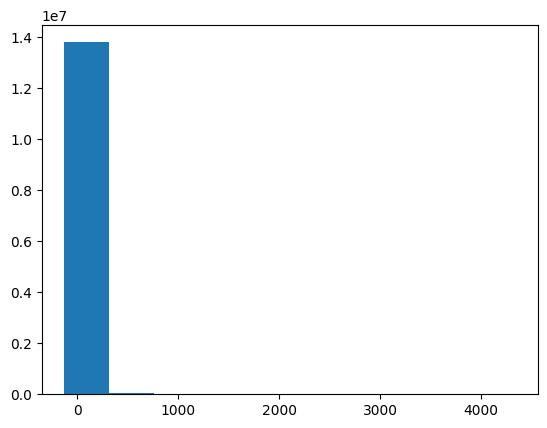

In [24]:
plt.hist(df['arr_delay'].sort_values(ignore_index=True));

In [59]:
class Transformer:
    def __init__(self, method='yeo-johnson'):
        self.pt = PowerTransformer(method=method)

    def fit(self, ds):
        X, y = ds[:]
        
        self.pt = self.pt.fit(y.to_numpy().reshape(-1, 1))
        
    def transform(self, ds, qbins=30, retweights=False):
        X, y = ds[:]
        name = y.name
                
        y = self.pt.transform(y.to_numpy().reshape(-1, 1))
        y = pd.Series(y.squeeze(-1), name=name)
        bins = pd.qcut(y, q=qbins, duplicates='drop')
        freq = bins.value_counts()

        if not retweights:
            return Dataset(X, y)
        
        else:
            weights = 1 / freq.reindex(bins).to_numpy()
            weights = weights.astype('float64')
            weights = weights / weights.mean()
            
            return Dataset(X, y), weights

In [60]:
tf = Transformer()
tf.fit(train_filtered)
# Weights for training
train_bal, weights = tf.transform(train_filtered, retweights=True)
val_bal = tf.transform(val_filtered)
test_bal = tf.transform(test_filtered)

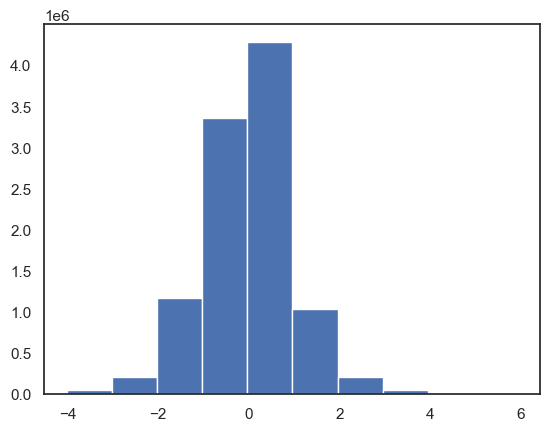

In [61]:
plt.hist(train_bal.y.sort_values(ignore_index=True));

## Normalize


In [31]:
class Standardizer:
    def __init__(self):
        self.mean = None
        self.STDV = None

    def fit(
            self,
            ds: Dataset,
            eps: float | None = 1e-3
    ):
        X, y = ds[:]

        self.mean = X.mean()
        self.STDV = X.std().clip(lower=eps)

        return self
    
    def transform(
            self,
            ds: Dataset
    ) -> Dataset:
        if self.mean is None or self.STDV is None:
            raise ValueError
        
        X, y = ds[:]

        X = (X - self.mean) / self.STDV

        return Dataset(X, y)

In [34]:
stdr = Standardizer()
stdr.fit(train_bal)
train_norm = stdr.transform(train_bal)
val_norm = stdr.transform(val_bal)
test_norm = stdr.transform(test_bal)

## Save Dataset


In [ ]:
train_final = pd.concat([train_norm.x.reset_index(drop=True), train_norm.y], axis=1)
val_final = pd.concat([val_norm.x.reset_index(drop=True), val_norm.y], axis=1)
test_final = pd.concat([test_norm.x.reset_index(drop=True), test_norm.y], axis=1)

BASE_DIR = Path('flight_data_2024_2025')
train_final.to_csv(os.path.join(BASE_DIR, 'train.csv'), index=False)
val_final.to_csv(os.path.join(BASE_DIR, 'valid.csv'), index=False)
test_final.to_csv(os.path.join(BASE_DIR, 'test.csv'), index=False)

In [47]:
import tarfile

archive_path = BASE_DIR.with_name(BASE_DIR.stem + '.tar.gz')

with tarfile.open(archive_path, 'w:gz') as tar:
    tar.add(BASE_DIR, arcname=BASE_DIR.name)

Run in terminal to extract folder:  
`tar -xzf archive.tar.gz -C /path/to/destination`
